# Demo del Paquete `toolbox_ml`

En este notebook se presenta una demostración interactiva de las funcionalidades de la librería `toolbox_ml`, un paquete diseñado para automatizar las fases de **Análisis Exploratorio de Datos (EDA)** y **Selección de Características (Feature Selection)** en proyectos de Machine Learning orientados a modelos de regresión.

In [1]:
import sys
sys.path.append("../")  # Para que busque en la carpeta del proyecto
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importamos el paquete desde la raiz
import toolbox_ml as tb

print(f"Versión de la librería cargada: {tb.__version__}")

Versión de la librería cargada: 1.0.0


## 1. Carga del Dataset de Prueba

Para evaluar el comportamiento de la librería, utilizaremos el dataset del **Titanic**. Aunque originalmente es un problema de clasificación, utilizaremos variables continuas como la tarifa (`fare`) o la edad (`age`) como objetivos para simular un escenario de regresión.

In [2]:
# Cargamos el dataset oficial desde los servidores de Seaborn
df_titanic = sns.load_dataset('titanic')

# Mostramos las primeras filas para comprobar que se ha cargado bien
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Fase de Análisis Descriptivo y Tipificación

A continuación, ejecutamos las funciones desarrolladas por la **Desarrolladora 1 (Marta)** para obtener un resumen estadístico de la calidad del dataset y una sugerencia automatizada del tipo de variables que componen el DataFrame.

In [3]:
# 2.1. Resumen descriptivo de nulos y cardinalidad
df_resumen = tb.describe_df(df_titanic)
display(df_resumen)

# 2.2. Tipificación automática de variables
# Editar los umbrales según criterio
df_tipos = tb.tipifica_variables(df_titanic, umbral_categorica=5, umbral_continua=10.0)
display(df_tipos)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
survived,int64,0.00,2,0.22
pclass,int64,0.00,3,0.34
sex,str,0.00,2,0.22
age,float64,19.87,88,9.88
sibsp,int64,0.00,7,0.79
parch,int64,0.00,7,0.79
fare,float64,0.00,248,27.83
embarked,str,0.22,3,0.34
class,category,0.00,3,0.34
who,str,0.00,3,0.34


,nombre_variable,tipo_sugerido
0,survived,Binaria
1,pclass,Categórica
2,sex,Binaria
3,age,Numérica Discreta
4,sibsp,Numérica Discreta
5,parch,Numérica Discreta
6,fare,Numérica Continua
7,embarked,Categórica
8,class,Categórica
9,who,Categórica


## 3. Fase de Feature Selection para Regresión

Utilizando las herramientas de la **Desarrolladora 2 (Claudia)**, realizamos el filtrado estadístico de variables basándonos en su relación con una variable objetivo cuantitativa (por ejemplo, `fare`).

Variables numéricas seleccionadas: ['pclass']


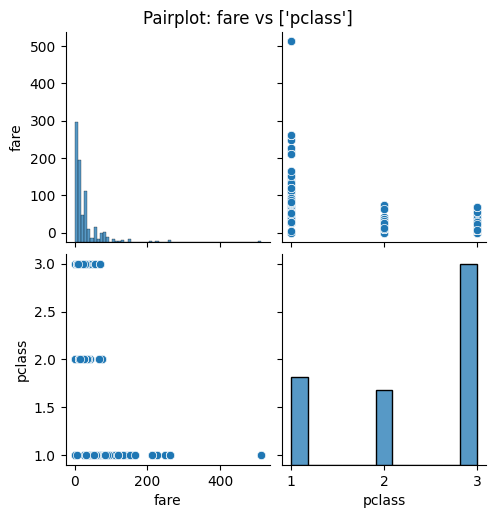

['pclass']

In [4]:
# 3.1 y 3.2 Selección de variables numéricas
# Pasamos 1 DataFrame, 2 columna objetivo ('fare'), 3 el umbral de correlación (0.5) y 4 p-valor máximo (0.05)
features_num = tb.get_features_num_regression(df_titanic, target_col='fare', umbral_corr=0.5, pvalue=0.05)
print("Variables numéricas seleccionadas:", features_num)

# Pintamos el gráfico descriptivo numérico del Dev.2 con los mismos parámetros
tb.plot_features_num_regression(df_titanic, target_col='fare', umbral_corr=0.5, pvalue=0.05)

Interpretación numéricas: Si quieres predecir el precio del billete (fare), la única variable numérica del dataset que realmente nos va a servir de forma clara es la clase del pasajero (pclass).

Variables categóricas seleccionadas: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


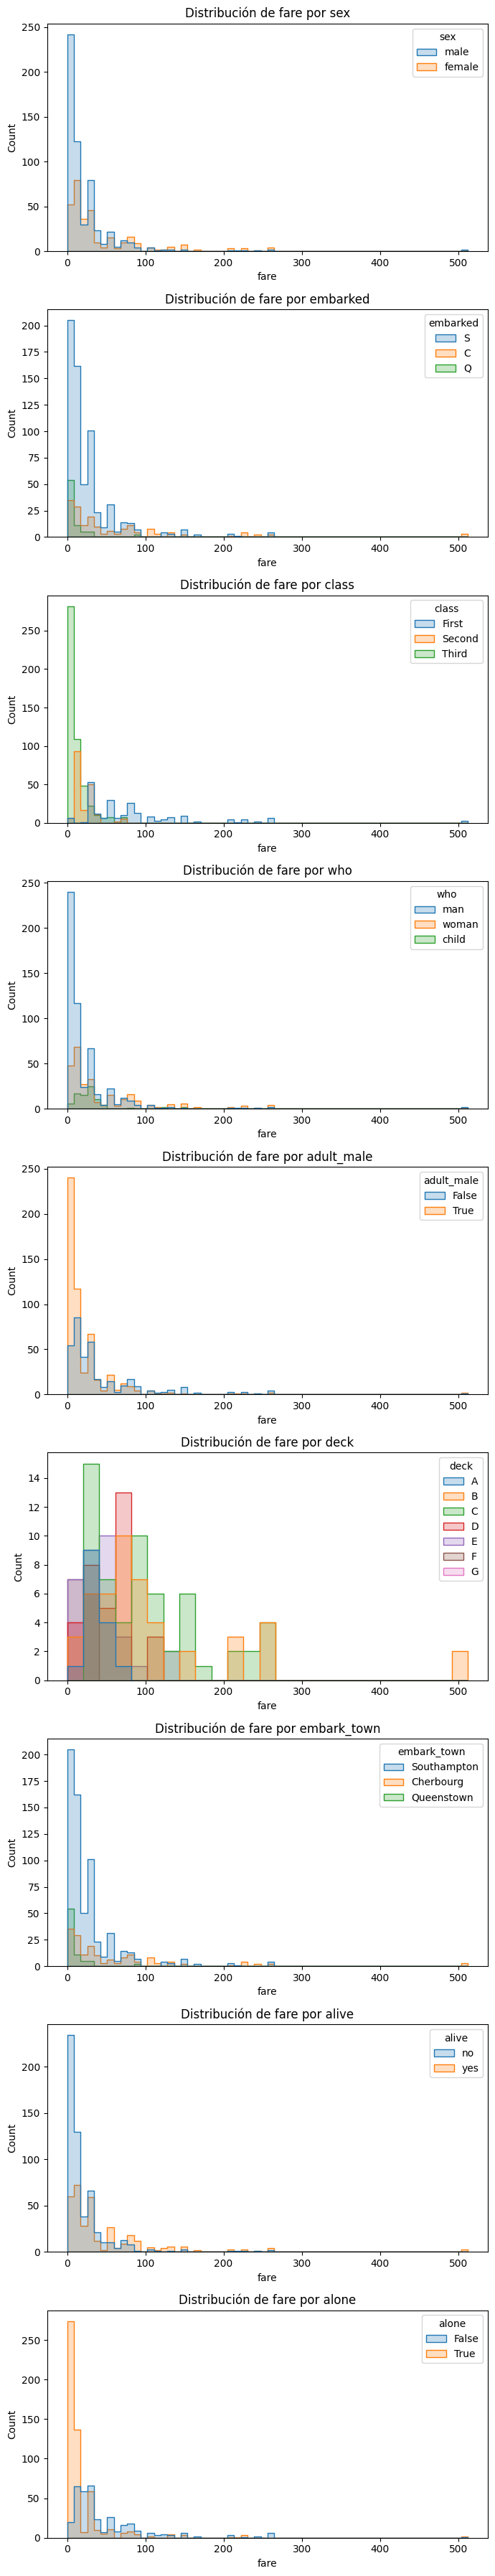

['sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [5]:
# 3.3. Selección de variables categóricas mediante ANOVA / Mann-Whitney U
features_cat = tb.get_features_cat_regression(df_titanic, target_col='fare', pvalue=0.05)
print("Variables categóricas seleccionadas:", features_cat)

# 3.4. Gráfico para las categóricas
tb.plot_features_cat_regression(df_titanic, target_col='fare', pvalue=0.05)

Interpretación: Nuestra función de selección de características categóricas ha funcionado a la perfección. Ha detectado de forma automatizada que el nivel socioeconómico del pasajero (reflejado en la clase, la cubierta y el puerto) junto a su perfil demográfico (si viaja solo, si es hombre, mujer o niño) son los factores determinantes que alteran el precio del billete (fare)"

## 4. Detección de outliers  
Bonus Nº1


In [6]:
# Detección automática de Outliers (Valores atípicos)
print("Análisis usando el método IQR (Rango Intercuartílico)")
resumen_outliers_iqr = tb.detect_outliers(df_titanic, method='iqr', threshold=1.5)

# Mostramos el resultado de la columna 'fare' (precio) ya que conocemos que tiene bastantes outliers
print(f"Outliers en 'fare' (IQR): {resumen_outliers_iqr['fare']['count']} valores ({resumen_outliers_iqr['fare']['percentage']}% del dataset)")

print("\nAnálisis usando el método Z-score (Umbral de 3 desviaciones)")
resumen_outliers_z = tb.detect_outliers(df_titanic, method='z_score', threshold=3.0)
print(f"Outliers en 'fare' (Z-score): {resumen_outliers_z['fare']['count']} valores ({resumen_outliers_z['fare']['percentage']}% del dataset)")

# Para ver, por ejemplo los índices de los primeros 10 outliers detectados en el precio:
print(f"\nPrimeros 10 índices con outlier en 'fare': {resumen_outliers_iqr['fare']['indices'][:10]}")

Análisis usando el método IQR (Rango Intercuartílico)
Outliers en 'fare' (IQR): 116 valores (13.02% del dataset)

Análisis usando el método Z-score (Umbral de 3 desviaciones)
Outliers en 'fare' (Z-score): 20 valores (2.24% del dataset)

Primeros 10 índices con outlier en 'fare': [1, 27, 31, 34, 52, 61, 62, 72, 88, 102]


## 5. Funciones equivalentes para clasificación

In [9]:
# El target ahora es 'survived' (0 = No sobrevive, 1 = Sobrevive)

features_num_clas = tb.get_features_num_classification(df_titanic, target='survived', pvalue_rango=0.05)
print(f"Variables numéricas importantes para predecir la supervivencia: {features_num_clas}")

features_cat_clas = tb.get_features_cat_classification(df_titanic, target='survived', pvalue_rango=0.05)
print(f"Variables categóricas importantes para predecir la supervivencia: {features_cat_clas}")

Variables numéricas importantes para predecir la supervivencia: ['pclass', 'age', 'parch', 'fare']
Variables categóricas importantes para predecir la supervivencia: ['sex', 'embarked', 'class', 'who', 'embark_town', 'alive']
